In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from pathlib import Path

# Hyperparamètres centralisés
VIDEO_PATH   = "exemple2.mp4"
OUTPUT_PATH  = "resultat.mp4"
FRAME_W, FRAME_H = 640, 360
TRACKER_TYPE = "CSRT"  # ou "KCF" spour plus de vitesse

# Fail early 
assert Path(VIDEO_PATH).exists(), f"Vidéo introuvable : {VIDEO_PATH}"
print(f"✓ {VIDEO_PATH} | OpenCV {cv2.__version__}")

✓ exemple2.mp4 | OpenCV 4.13.0


Résolution native : 360x640
Résolution de travail : 640x360
FPS : 30.0 | Frames : 435 | Durée : 14.5s


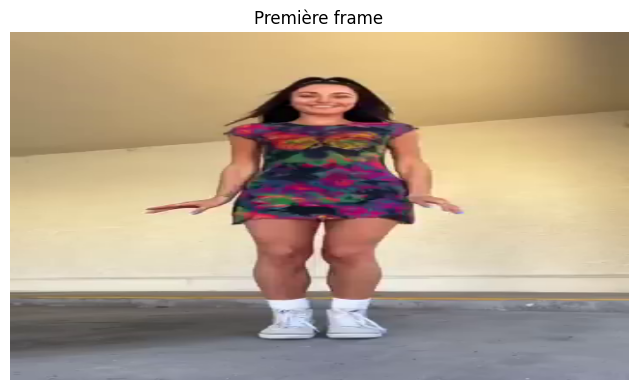

In [2]:
cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), "Impossible d'ouvrir la vidéo"

# On récupère les métadonnées natives de la vidéo
FPS          = cap.get(cv2.CAP_PROP_FPS)
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W_NATIVE     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H_NATIVE     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
DURATION     = TOTAL_FRAMES / FPS

print(f"Résolution native : {W_NATIVE}x{H_NATIVE}")
print(f"Résolution de travail : {FRAME_W}x{FRAME_H}")
print(f"FPS : {FPS:.1f} | Frames : {TOTAL_FRAMES} | Durée : {DURATION:.1f}s")

# On lit la première frame pour pouvoir sélectionner la ROI dessus (cellule suivante)
# On la garde en BGR (format OpenCV) ET en niveaux de gris (pour l'optical flow)
ret, first_frame = cap.read()
assert ret, "Impossible de lire la première frame"

first_frame = cv2.resize(first_frame, (FRAME_W, FRAME_H))
first_gray  = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)

# On remet le curseur au début — on relit tout depuis le début à la prochaine étape
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

# Affichage de la première frame dans le notebook
plt.figure(figsize=(8, 4))
plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
plt.title("Première frame")
plt.axis("off")
plt.tight_layout()
plt.show()


✓ ROI : x=251, y=265, w=69, h=71


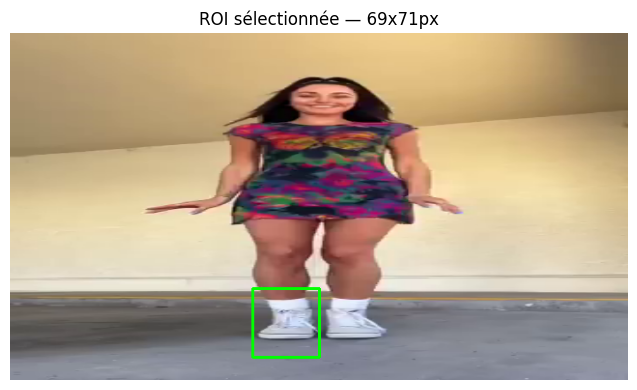

In [3]:
# cv2.selectROI ouvre une fenêtre native OpenCV.
# Tu cliques-glisses pour dessiner le rectangle.
# ESPACE ou ENTRÉE pour valider — C pour annuler.
#
# Retourne un tuple (x, y, w, h) en pixels dans la résolution de travail.
# Si tu annules, retourne (0, 0, 0, 0).

roi = cv2.selectROI(
    "Sélectionne la zone à tracker — ESPACE pour valider",
    first_frame,
    fromCenter=False,   # le rectangle part du coin supérieur gauche du clic
    showCrosshair=True
)
cv2.destroyAllWindows()

x, y, w, h = (int(v) for v in roi)
assert w > 0 and h > 0, "ROI vide — relance la cellule et sélectionne une zone"

ROI = (x, y, w, h)
print(f"✓ ROI : x={x}, y={y}, w={w}, h={h}")

# Vérification visuelle dans le notebook
preview = first_frame.copy()
cv2.rectangle(preview, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.figure(figsize=(8, 4))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.title(f"ROI sélectionnée — {w}x{h}px")
plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
# KCF  : corrélation dans l'espace fréquentiel — rapide, bon sur mouvements réguliers
# CSRT : recherche spatiale contrainte — plus lent mais robuste aux déformations
# CSRT pour les membres du corps (forme qui change)

def make_tracker(tracker_type: str):
    trackers = {
        "KCF"  : cv2.TrackerKCF_create,
        "CSRT" : cv2.TrackerCSRT_create,
    }
    assert tracker_type in trackers, f"Tracker inconnu : {tracker_type}"
    return trackers[tracker_type]()

# On instancie le tracker et on l'initialise sur la première frame + ROI.
# À partir de là, il apprend l'apparence visuelle de la zone sélectionnée.
tracker = make_tracker(TRACKER_TYPE)
tracker.init(first_frame, ROI)

print(f"✓ Tracker {TRACKER_TYPE} initialisé sur ROI {ROI}")

✓ Tracker CSRT initialisé sur ROI (251, 265, 69, 71)


In [5]:
# On repart du début de la vidéo
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ret, frame = cap.read()
frame      = cv2.resize(frame, (FRAME_W, FRAME_H))
prev_gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

current_roi = ROI
signal_raw  = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (FRAME_W, FRAME_H))
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 1. Le tracker prédit la nouvelle position de la ROI dans cette frame
    ok, bbox = tracker.update(frame)
    if ok:
        current_roi = tuple(int(v) for v in bbox)

    # 2. Optical flow de Farneback sur toute la frame (dense)
    #    donne un vecteur (dx, dy) pour chaque pixel
    #    pyr_scale=0.5 : pyramide gaussienne, chaque niveau réduit de moitié
    #    levels=3      : 3 niveaux de résolution pour capturer grands et petits mouvements
    #    winsize=15    : taille de la fenêtre de lissage polynomial
    #    iterations=3  : passes de raffinement par niveau
    #    poly_n=5      : voisinage pour l'approximation polynomiale locale
    #    poly_sigma=1.2: écart-type du noyau gaussien de pondération
    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, gray, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0
    )

    # 3. On extrait uniquement la sous-matrice du flow dans la ROI trackée
    rx, ry, rw, rh = current_roi
    rx, ry = max(0, rx), max(0, ry)   # sécurisation des bornes
    roi_flow = flow[ry:ry+rh, rx:rx+rw]

    # cartToPolar convertit (dx, dy) : (magnitude, angle)
    # On garde uniquement la magnitude = intensité du mouvement
    mag, _ = cv2.cartToPolar(roi_flow[..., 0], roi_flow[..., 1])
    signal_raw.append(float(np.mean(mag)))

    prev_gray = gray

cap.release()
print(f"✓ {len(signal_raw)} frames analysées")

import pandas as pd

SAVE_CSV = True
CSV_PATH = "frames_output.csv"

if SAVE_CSV:
    df = pd.DataFrame({
        "frame": list(range(len(signal_raw)))
    })
    df.to_csv(CSV_PATH, index=False)
    print(f"✓ CSV frames sauvegardé : {CSV_PATH}")
  

✓ 434 frames analysées
✓ CSV frames sauvegardé : frames_output.csv


Répétitions détectées : 19
Cadence              : 79.0 reps/min
Durée moyenne/rep    : 0.75s


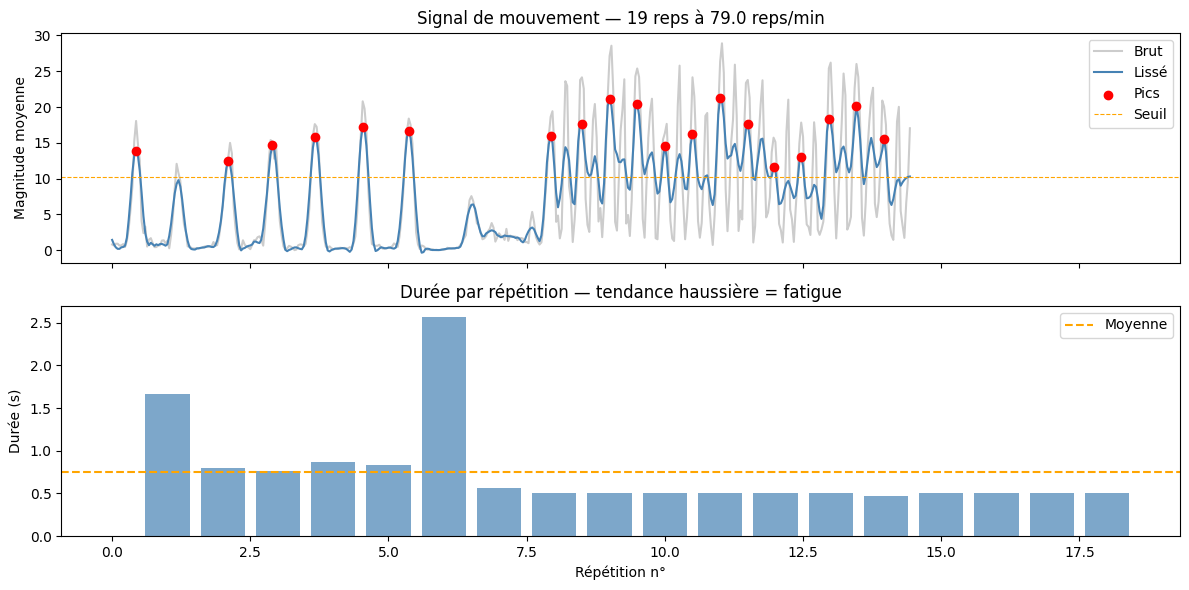

In [6]:
signal = np.array(signal_raw, dtype=np.float32)
times  = np.arange(len(signal)) / FPS   # axe temporel en secondes

# Savitzky-Golay : lisse le signal en ajustant un polynôme local
# sur une fenêtre glissante — préserve mieux les pics que la moyenne mobile.
# window_length doit être impair et > polyorder.
signal_smooth = savgol_filter(signal, window_length=11, polyorder=2)

# distance=10 : deux pics ne peuvent pas être à moins de 10 frames d'écart
# évite de compter deux fois le même mouvement
# height      : seuil minimum — on ignore les micro-mouvements parasites
threshold = np.mean(signal_smooth) + 0.5 * np.std(signal_smooth)
peaks, _  = find_peaks(signal_smooth, distance=10, height=threshold)

# Métriques extraites du signal
nb_reps  = len(peaks)
cadence  = nb_reps / (times[-1] / 60)   # reps par minute

if nb_reps > 1:
    inter_peak = np.diff(peaks) / FPS       # durée entre chaque rep (secondes)
    avg_rep_duration = np.mean(inter_peak)
else:
    avg_rep_duration = 0

print(f"Répétitions détectées : {nb_reps}")

print(f"Cadence              : {cadence:.1f} reps/min")
print(f"Durée moyenne/rep    : {avg_rep_duration:.2f}s")

# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(times, signal, alpha=0.4, color="gray", label="Brut")
axes[0].plot(times, signal_smooth, color="steelblue", label="Lissé")
axes[0].scatter(times[peaks], signal_smooth[peaks], color="red", zorder=5, label="Pics")
axes[0].axhline(threshold, color="orange", linestyle="--", linewidth=0.8, label="Seuil")
axes[0].set_ylabel("Magnitude moyenne")
axes[0].legend()
axes[0].set_title(f"Signal de mouvement — {nb_reps} reps à {cadence:.1f} reps/min")

# Durée de chaque rep pour détecter la fatigue (ralentissement)
if nb_reps > 1:
    axes[1].bar(range(1, nb_reps), inter_peak, color="steelblue", alpha=0.7)
    axes[1].axhline(avg_rep_duration, color="orange", linestyle="--", label="Moyenne")
    axes[1].set_xlabel("Répétition n°")
    axes[1].set_ylabel("Durée (s)")
    axes[1].set_title("Durée par répétition — tendance haussière = fatigue")
    axes[1].legend()

plt.tight_layout()
plt.show()


In [7]:
def signal_to_img(signal, peaks, idx, w=320, h=160):
    fig, ax = plt.subplots(figsize=(3.5, 1.8), dpi=80)

    ax.plot(signal[:idx], color="cyan", linewidth=1.0)

    visible_peaks = [p for p in peaks if p < idx]
    if visible_peaks:
        ax.scatter(visible_peaks, signal[visible_peaks],
                   color="red", s=12, zorder=5, label=f"{len(visible_peaks)} reps")
        ax.legend(fontsize=6, loc="upper left",
                  facecolor="#222", labelcolor="white", edgecolor="none")

    # Ligne verticale = position actuelle dans la vidéo
    ax.axvline(idx, color="yellow", linewidth=0.8, alpha=0.7)

    ax.set_xlim(0, len(signal))
    ax.set_ylim(0, signal.max() * 1.1)

    ax.set_xlabel("Frame", fontsize=6, color="white")
    ax.set_ylabel("Mouvement", fontsize=6, color="white")
    ax.set_title("Signal ROI", fontsize=7, color="white", pad=3)

    ax.tick_params(axis="both", labelsize=5, colors="white")
    ax.spines[:].set_color("#555")
    ax.set_facecolor("#1a1a1a")
    fig.patch.set_facecolor("#1a1a1a")

    fig.tight_layout(pad=0.4)
    fig.canvas.draw()
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    buf = buf.reshape(fig.canvas.get_width_height()[::-1] + (4,))[..., :3]
    plt.close(fig)
    return cv2.cvtColor(cv2.resize(buf, (w, h)), cv2.COLOR_RGB2BGR)
  

# ── Réinitialisation pour rejouer depuis le début ──────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)  
ret, frame = cap.read()
assert ret, "Impossible de lire la première frame"
frame     = cv2.resize(frame, (FRAME_W, FRAME_H))
prev_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
tracker    = make_tracker(TRACKER_TYPE)
tracker.init(frame, ROI)
current_roi = ROI

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out    = cv2.VideoWriter(OUTPUT_PATH, fourcc, FPS, (FRAME_W, FRAME_H))
peaks_set = set(peaks.tolist())
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (FRAME_W, FRAME_H))
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    ok, bbox = tracker.update(frame)
    if ok:
        current_roi = tuple(int(v) for v in bbox)

    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, gray, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0
    )
    # Vecteurs de flux uniquement dans la ROI (step=12 pour ne pas surcharger)
    rx, ry, rw, rh = current_roi
    for fy in range(ry, min(ry+rh, FRAME_H), 12):
        for fx in range(rx, min(rx+rw, FRAME_W), 12):
            dx, dy = flow[fy, fx]
            cv2.arrowedLine(frame, (fx, fy),
                            (int(fx+dx*2), int(fy+dy*2)),
                            (0, 255, 0), 1, tipLength=0.4)

    # Rectangle du tracker — vert si ok, rouge si perdu
    color = (0, 255, 0) if ok else (0, 0, 255)
    cv2.rectangle(frame, (rx, ry), (rx+rw, ry+rh), color, 2)

    # Indicateur BEAT sur les frames correspondant à un pic
    if frame_idx in peaks_set:
        cv2.putText(frame, "BEAT", (50, 60),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3)

    # Graphe du signal en incrustation (coin bas-droit)
    graph = signal_to_img(signal_smooth, peaks, frame_idx)
    gh, gw = graph.shape[:2]
    frame[FRAME_H-gh:, FRAME_W-gw:] = graph

    # Compteur de reps et cadence en temps réel
    reps_so_far = sum(1 for p in peaks if p <= frame_idx)
    cv2.putText(frame, f"Reps: {reps_so_far}/{nb_reps}", (10, FRAME_H-12),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    out.write(frame)
    cv2.imshow("Rendu — Q pour quitter", frame)
    if cv2.waitKey(1) & 0xFF in (27, ord("q")):
        break

    prev_gray = gray
    frame_idx += 1

cap.release()
out.release()
cv2.destroyAllWindows()
print(f"✓ Vidéo sauvegardée : {OUTPUT_PATH}")

✓ Vidéo sauvegardée : resultat.mp4


✓ 16 points Shi-Tomasi détectés


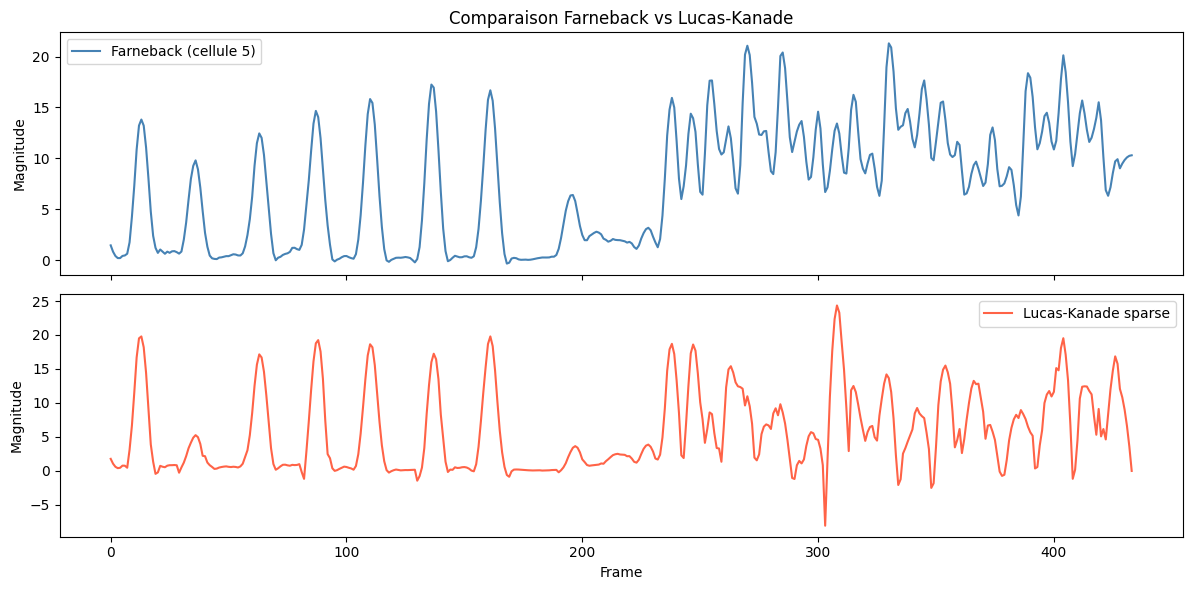

✓ 434 frames analysées
✓ CSV sauvegardé : optical_flow_lk.csv


In [8]:
# ── Pourquoi Lucas-Kanade sparse ? ─────────────────────────────────────
# Farneback calcule le flux sur TOUS les pixels → beaucoup de bruit.
# LK ne suit que ~100 points d'intérêt détectés par Shi-Tomasi,
# ceux qui ont un fort gradient dans les deux directions (coins, textures).
# Résultat : signal plus propre, calcul plus rapide.

# Paramètres Shi-Tomasi — détection des points d'intérêt dans la ROI
SHITOMASI_PARAMS = dict(
    maxCorners=100,      # nombre max de points détectés
    qualityLevel=0.01,  # seuil de qualité relatif au meilleur point trouvé
    minDistance=7,      # distance minimale entre deux points (évite les doublons)
    blockSize=7         # taille du voisinage pour le calcul du gradient
)

# Paramètres Lucas-Kanade — suivi des points entre deux frames
# winSize   : fenêtre de recherche autour de chaque point
# maxLevel  : niveaux de pyramide (comme Farneback, pour capturer grands mouvements)
# criteria  : on arrête quand le déplacement < 0.03px OU après 20 itérations
LK_PARAMS = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 20, 0.03)
)

def detect_points_in_roi(gray, roi):
    """Détecte les points Shi-Tomasi uniquement dans la zone ROI."""
    x, y, w, h = roi
    mask = np.zeros_like(gray)
    mask[y:y+h, x:x+w] = 255   # on autorise la détection seulement dans la ROI
    pts = cv2.goodFeaturesToTrack(gray, mask=mask, **SHITOMASI_PARAMS)
    return pts  # shape (N, 1, 2) ou None si rien trouvé

# ── Boucle LK ───────────────────────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
frame     = cv2.resize(frame, (FRAME_W, FRAME_H))
prev_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Détection initiale des points dans la ROI sélectionnée en cellule 3
prev_pts = detect_points_in_roi(prev_gray, ROI)
assert prev_pts is not None, "Aucun point détecté dans la ROI — agrandis-la"
print(f"✓ {len(prev_pts)} points Shi-Tomasi détectés")

signal_lk  = []   # magnitude moyenne des déplacements
signal_dx  = []   # composante horizontale moyenne
signal_dy  = []   # composante verticale moyenne (signe = direction)
REDETECT_EVERY = 15  # on re-détecte les points toutes les N frames

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (FRAME_W, FRAME_H))
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Calcul LK : pour chaque point, trouve sa nouvelle position dans gray
    # status : 1 si le point a été retrouvé, 0 sinon
    next_pts, status, _ = cv2.calcOpticalFlowPyrLK(
        prev_gray, gray, prev_pts, None, **LK_PARAMS
    )

    # On garde uniquement les points bien trackés (status == 1)
    good_prev = prev_pts[status == 1]
    good_next = next_pts[status == 1]

    if len(good_prev) > 0:
        displacements = good_next - good_prev          # shape (N, 2)
        dx = displacements[:, 0]
        dy = displacements[:, 1]
        mag = np.sqrt(dx**2 + dy**2)
        signal_lk.append(float(np.mean(mag)))
        signal_dx.append(float(np.mean(dx)))
        signal_dy.append(float(np.mean(dy)))
    else:
        signal_lk.append(0.0)
        signal_dx.append(0.0)
        signal_dy.append(0.0)

    # Re-détection périodique pour garder les points dans la ROI
    if frame_idx % REDETECT_EVERY == 0:
        prev_pts = detect_points_in_roi(gray, ROI)
        if prev_pts is None:
            prev_pts = good_next.reshape(-1, 1, 2)  # fallback sur les points actuels
    else:
        prev_pts = good_next.reshape(-1, 1, 2)

    prev_gray = gray
    frame_idx += 1

cap.release()
# Conversion en arrays numpy + lissage
signal_lk = np.array(signal_lk, dtype=np.float32)
signal_dx = np.array(signal_dx, dtype=np.float32)
signal_dy = np.array(signal_dy, dtype=np.float32)
signal_lk_smooth = savgol_filter(signal_lk, window_length=11, polyorder=2)

# Comparaison visuelle Farneback vs Lucas-Kanade
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(signal_smooth, color="steelblue", label="Farneback (cellule 5)")
axes[0].set_title("Comparaison Farneback vs Lucas-Kanade")
axes[0].set_ylabel("Magnitude")
axes[0].legend()

axes[1].plot(signal_lk_smooth, color="tomato", label="Lucas-Kanade sparse")
axes[1].set_ylabel("Magnitude")
axes[1].set_xlabel("Frame")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"✓ {len(signal_lk)} frames analysées")
import csv

CSV_PATH = "optical_flow_lk.csv"

with open(CSV_PATH, mode="w", newline="") as f:
    writer = csv.writer(f)

    # Header (comme dans ton Excel)
    writer.writerow(["frame", "mag", "dx", "dy"])

    # Données ligne par ligne
    for i in range(len(signal_lk)):
        writer.writerow([
            i,
            signal_lk[i],
            signal_dx[i],
            signal_dy[i]
        ])

print(f"✓ CSV sauvegardé : {CSV_PATH}")

Transitions détectées  : 72
Phase montée  (conc.)  : 0.25s moyenne
Phase descente (exc.)  : 0.16s moyenne


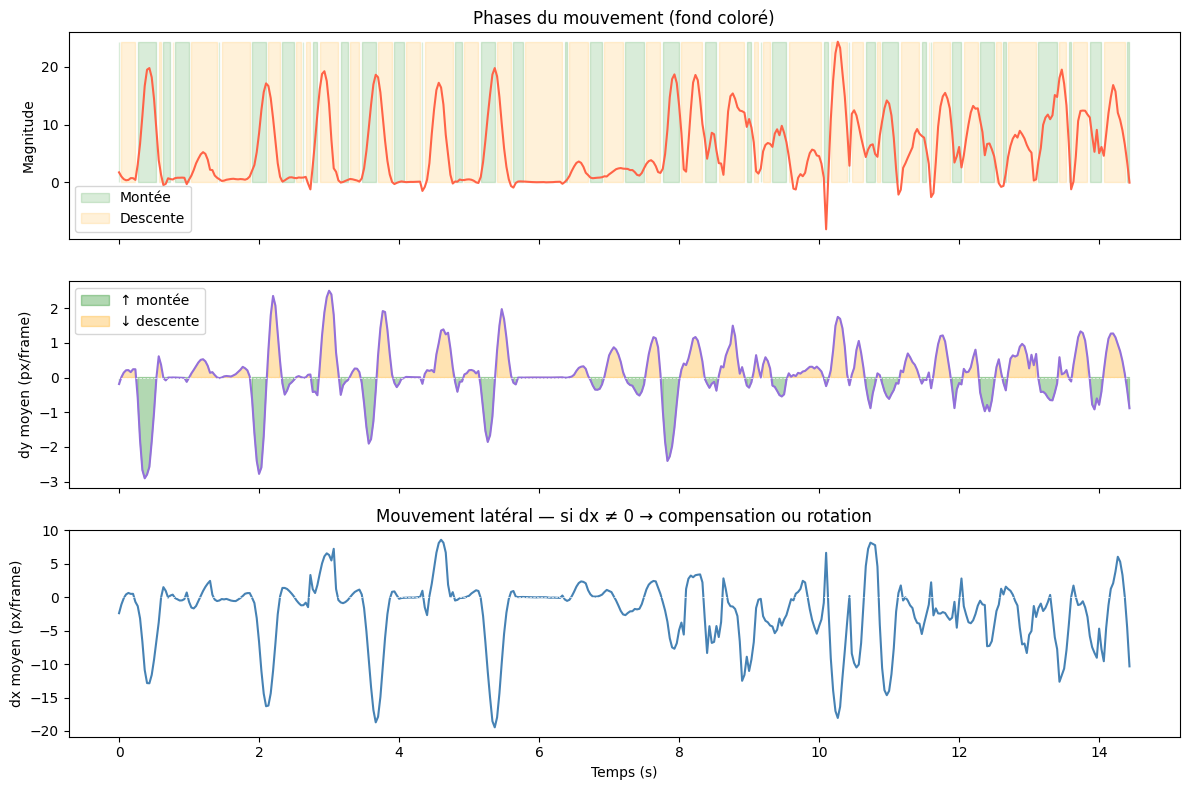

In [9]:
# ── Idée centrale ───────────────────────────────────────────────────────
# Le signe de dy moyen indique la direction verticale dominante :
#   dy < 0 : mouvement vers le haut  (phase concentrique pour un curl)
#   dy > 0 : mouvement vers le bas   (phase excentrique)
# On peut faire pareil avec dx pour les mouvements latéraux.
# Attention : en OpenCV y=0 est en HAUT de l'image → dy négatif = montée

dy_smooth = savgol_filter(signal_dy, window_length=11, polyorder=2)
dx_smooth = savgol_filter(signal_dx, window_length=11, polyorder=2)

# Segmentation des phases selon le signe de dy
# On lisse d'abord pour éviter les micro-inversions parasites
phase = np.where(dy_smooth < 0, 1, -1)  # 1 = montée, -1 = descente

# Détection des changements de phase = transitions concentrique ↔ excentrique
transitions = np.where(np.diff(phase) != 0)[0]

# Durée de chaque phase (en secondes)
phase_durations = np.diff(transitions) / FPS
up_durations   = phase_durations[phase[transitions[:-1]] == 1]
down_durations = phase_durations[phase[transitions[:-1]] == -1]

print(f"Transitions détectées  : {len(transitions)}")
if len(up_durations) > 0:
    print(f"Phase montée  (conc.)  : {up_durations.mean():.2f}s moyenne")
if len(down_durations) > 0:
    print(f"Phase descente (exc.)  : {down_durations.mean():.2f}s moyenne")

# ── Visualisation ───────────────────────────────────────────────────────
times = np.arange(len(dy_smooth)) / FPS

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Signal de magnitude avec les phases en fond
axes[0].plot(times, signal_lk_smooth, color="tomato")
axes[0].fill_between(times, 0, signal_lk_smooth.max(),
    where=(phase == 1),
    alpha=0.15, color="green", label="Montée")
axes[0].fill_between(times, 0, signal_lk_smooth.max(),
    where=(phase == -1),
    alpha=0.15, color="orange", label="Descente")
axes[0].set_ylabel("Magnitude")
axes[0].set_title("Phases du mouvement (fond coloré)")
axes[0].legend()

# dy brut : le signe donne la direction
axes[1].plot(times, dy_smooth, color="mediumpurple")
axes[1].axhline(0, color="white", linewidth=0.5, linestyle="--")
axes[1].fill_between(times, dy_smooth, 0,
    where=(dy_smooth < 0), alpha=0.3, color="green", label="↑ montée")
axes[1].fill_between(times, dy_smooth, 0,
    where=(dy_smooth > 0), alpha=0.3, color="orange", label="↓ descente")
axes[1].set_ylabel("dy moyen (px/frame)")
axes[1].legend()

# dx : mouvement latéral (compensation ou rotation)
axes[2].plot(times, dx_smooth, color="steelblue")
axes[2].axhline(0, color="white", linewidth=0.5, linestyle="--")
axes[2].set_ylabel("dx moyen (px/frame)")
axes[2].set_xlabel("Temps (s)")
axes[2].set_title("Mouvement latéral — si dx ≠ 0 → compensation ou rotation")

plt.tight_layout()
plt.show()


In [10]:
# ── Idée centrale ───────────────────────────────────────────────────────
# On encode la direction du flux optique dans la couleur des vecteurs.
# Représentation HSV :
#   Hue : angle du vecteur (direction)  : 0°=rouge, 120°=vert, 240°=bleu
#   Value  : magnitude (intensité)         : noir si immobile, vif si rapide
#   Saturation : fixée à 255 (couleur pure)
#
# C'est la visualisation standard de l'optical flow en couleur.
# Elle permet de voir d'un coup d'œil quelles zones bougent
# dans quelle direction.

def flow_to_hsv(flow):
    """Convertit un champ de flux optique en image BGR colorée par direction."""
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    hsv = np.zeros((*flow.shape[:2], 3), dtype=np.uint8)
    hsv[..., 0] = ang * 180 / np.pi / 2   # Hue : angle → [0, 180] (format OpenCV)
    hsv[..., 1] = 255                        # Saturation : toujours max
    hsv[..., 2] = cv2.normalize(            # Value : magnitude normalisée
        mag, None, 0, 255, cv2.NORM_MINMAX
    )
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

# ── Rendu vidéo ─────────────────────────────────────────────────────────
OUTPUT_COLORED = "resultat_couleurs.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
frame     = cv2.resize(frame, (FRAME_W, FRAME_H))
prev_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out    = cv2.VideoWriter(OUTPUT_COLORED, fourcc, FPS, (FRAME_W * 2, FRAME_H))
# Vidéo en side-by-side : frame originale | visualisation HSV du flux

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (FRAME_W, FRAME_H))
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, gray, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0
    )
    flow_img = flow_to_hsv(flow)

    # Rectangle ROI sur les deux côtés
    rx, ry, rw, rh = ROI
    cv2.rectangle(frame,    (rx, ry), (rx+rw, ry+rh), (255, 255, 255), 1)
    cv2.rectangle(flow_img, (rx, ry), (rx+rw, ry+rh), (255, 255, 255), 1)

    # Labels
    cv2.putText(frame,    "Original",  (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1)
    cv2.putText(flow_img, "Flux (HSV)", (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1)

    combined = np.hstack([frame, flow_img])
    out.write(combined)
    cv2.imshow("Original | Flux HSV — Q pour quitter", combined)
    if cv2.waitKey(1) & 0xFF in (27, ord("q")):
        break

    prev_gray = gray

cap.release()
out.release()
cv2.destroyAllWindows()
print(f"✓ Vidéo sauvegardée : {OUTPUT_COLORED}")

✓ Vidéo sauvegardée : resultat_couleurs.mp4


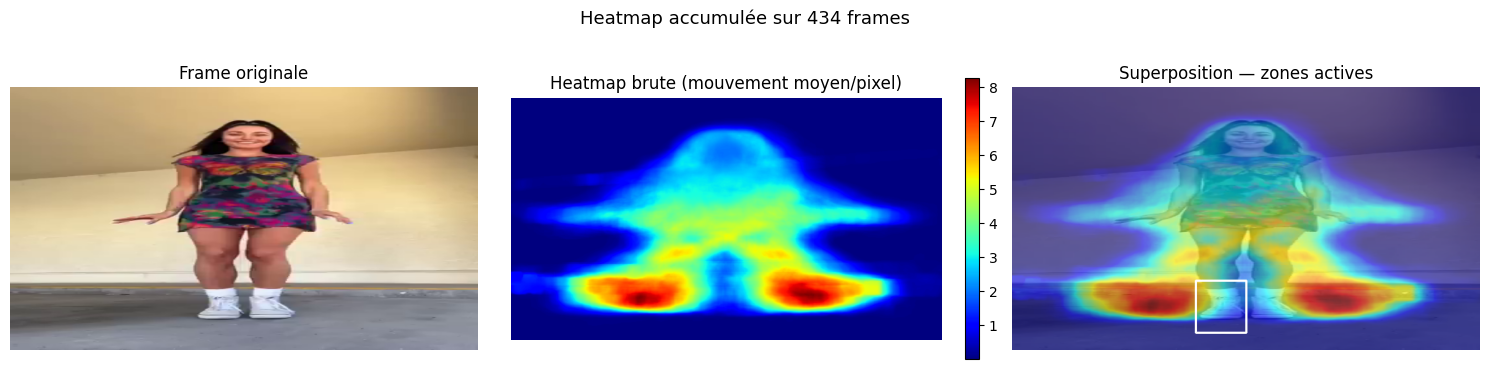

heatmap_mouvement.png sauvegardée


In [11]:
# ── Idée centrale ───────────────────────────────────────────────────────
# On accumule la magnitude du flux optique pixel par pixel sur toute
# la vidéo : une matrice (H, W) où chaque valeur = mouvement total
# observé en ce point.
# Les zones chaudes = endroits qui ont le plus bougé.
# Utile pour détecter des compensations : une zone qui ne devrait pas
# bouger mais apparaît chaude sur la heatmap.

cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
frame     = cv2.resize(frame, (FRAME_W, FRAME_H))
prev_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Matrice d'accumulation — float32 pour éviter le dépassement
heatmap = np.zeros((FRAME_H, FRAME_W), dtype=np.float32)
n_frames = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (FRAME_W, FRAME_H))
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, gray, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0
    )

    mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    heatmap += mag   # accumulation pixel par pixel

    prev_gray = gray
    n_frames += 1

cap.release()

# Normalisation : on divise par le nombre de frames
# valeur moyenne de mouvement par pixel, indépendante de la durée
heatmap /= n_frames

# Conversion en image 8 bits pour l'affichage et la colormap
heatmap_norm = cv2.normalize(heatmap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
heatmap_color = cv2.applyColorMap(heatmap_norm, cv2.COLORMAP_JET)
# COLORMAP_JET : bleu (froid, peu de mouvement) → rouge (chaud, beaucoup)

# Récupérer la première frame pour la superposition
cap = cv2.VideoCapture(VIDEO_PATH)
_, first = cap.read()
cap.release()
first = cv2.resize(first, (FRAME_W, FRAME_H))

# Superposition heatmap + frame originale (alpha blending)
# alpha=0.6 : la heatmap reste lisible sans cacher complètement l'image
overlay = cv2.addWeighted(first, 0.4, heatmap_color, 0.6, 0)

# Rectangle ROI pour référence
rx, ry, rw, rh = ROI
cv2.rectangle(overlay, (rx, ry), (rx+rw, ry+rh), (255, 255, 255), 2)

# ── Visualisation matplotlib ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(cv2.cvtColor(first, cv2.COLOR_BGR2RGB))
axes[0].set_title("Frame originale")
axes[0].axis("off")

im = axes[1].imshow(heatmap, cmap="jet")
axes[1].set_title("Heatmap brute (mouvement moyen/pixel)")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.03)

axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[2].set_title("Superposition — zones actives")
axes[2].axis("off")

plt.suptitle(f"Heatmap accumulée sur {n_frames} frames", fontsize=13)
plt.tight_layout()
plt.savefig("heatmap_mouvement.png", dpi=150)
plt.show()
print("heatmap_mouvement.png sauvegardée")


✓ ROI 1 : (254, 276, 64, 48)
✓ ROI 2 : (333, 273, 65, 54)
ROI 1 vs ROI 2 — corrélation max : 0.498 | lag : +0.00s


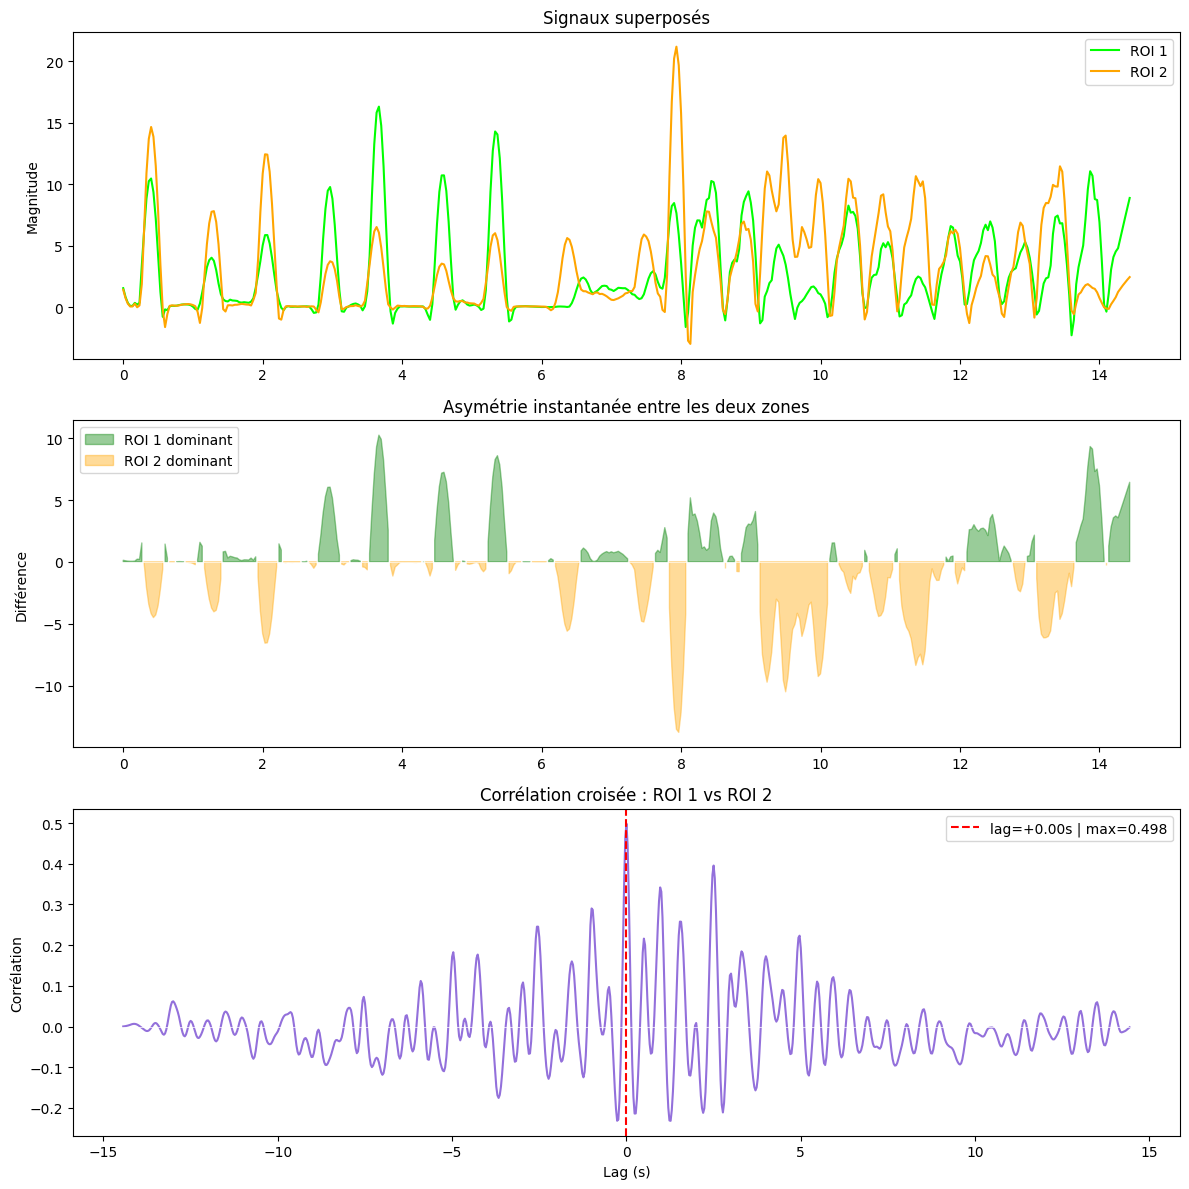

In [15]:
# ── Idée centrale ───────────────────────────────────────────────────────
# On sélectionne N zones indépendantes (ex: bras gauche, bras droit).
# Chaque ROI produit son propre signal de mouvement.
# La corrélation croisée entre deux signaux mesure leur similarité :
#   corr ≈ 1  : mouvements synchrones (symétrique)
#   corr ≈ 0  : mouvements indépendants
#   corr < 0  : mouvements opposés (alterné)
# Le lag au pic de corrélation = décalage temporel entre les deux zones.

N_ROIS = 2   # change selon ton besoin
ROI_COLORS = [(0, 255, 0), (0, 165, 255), (0, 0, 255)]  # vert, orange, rouge
ROI_LABELS = [f"ROI {i+1}" for i in range(N_ROIS)]

# Sélection interactive des N ROIs l'une après l'autre
rois = []
for i in range(N_ROIS):
    preview = first_frame.copy()
    for j, r in enumerate(rois):   # affiche les ROIs déjà sélectionnées
        cv2.rectangle(preview, (r[0], r[1]), (r[0]+r[2], r[1]+r[3]), ROI_COLORS[j], 2)

    roi = cv2.selectROI(f"ROI {i+1}/{N_ROIS} — ESPACE pour valider", preview,
                        fromCenter=False, showCrosshair=True)
    cv2.destroyAllWindows()
    x, y, w, h = (int(v) for v in roi)
    assert w > 0 and h > 0, f"ROI {i+1} vide"
    rois.append((x, y, w, h))
    print(f"✓ ROI {i+1} : {(x, y, w, h)}")


# ── Boucle : un signal par ROI ───────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
frame     = cv2.resize(frame, (FRAME_W, FRAME_H))
prev_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

signals = [[] for _ in range(N_ROIS)]

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (FRAME_W, FRAME_H))
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, gray, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0
    )
    for i, (rx, ry, rw, rh) in enumerate(rois):
        roi_flow = flow[ry:ry+rh, rx:rx+rw]
        mag, _   = cv2.cartToPolar(roi_flow[..., 0], roi_flow[..., 1])
        signals[i].append(float(np.mean(mag)))

    prev_gray = gray

cap.release()

# Lissage de chaque signal
signals_smooth = [
    savgol_filter(np.array(s, dtype=np.float32), window_length=11, polyorder=2)
    for s in signals
]
times = np.arange(len(signals_smooth[0])) / FPS

# ── Corrélation croisée entre toutes les paires ─────────────────────────
# np.correlate en mode "full" donne la corrélation à tous les décalages.
# Le pic indique le lag optimal entre les deux signaux.
from itertools import combinations


corr_results = {}
for i, j in combinations(range(N_ROIS), 2):
    a = signals_smooth[i] - signals_smooth[i].mean()
    b = signals_smooth[j] - signals_smooth[j].mean()
    corr = np.correlate(a, b, mode="full")
    corr /= (np.std(a) * np.std(b) * len(a))   # normalisation → [-1, 1]
    lag   = (np.argmax(corr) - (len(a) - 1)) / FPS
    peak  = corr.max()
    corr_results[(i, j)] = (corr, lag, peak)
    print(f"ROI {i+1} vs ROI {j+1} — corrélation max : {peak:.3f} | lag : {lag:+.2f}s")

# ── Visualisation ────────────────────────────────────────────────────────
n_pairs = len(corr_results)
fig, axes = plt.subplots(2 + n_pairs, 1, figsize=(12, 4 * (2 + n_pairs)), sharex=False)

# Signaux superposés
for i, s in enumerate(signals_smooth):
    c = [x/255 for x in ROI_COLORS[i][::-1]]  # BGR → RGB normalisé
    axes[0].plot(times, s, color=c, label=ROI_LABELS[i])
axes[0].set_ylabel("Magnitude")
axes[0].set_title("Signaux superposés")
axes[0].legend()

# Différence entre les signaux (asymétrie instantanée)
diff = signals_smooth[0] - signals_smooth[1]
axes[1].fill_between(times, diff, 0,
    where=(diff > 0), color="green",  alpha=0.4, label=f"{ROI_LABELS[0]} dominant")
axes[1].fill_between(times, diff, 0,
    where=(diff < 0), color="orange", alpha=0.4, label=f"{ROI_LABELS[1]} dominant")
axes[1].axhline(0, color="white", linewidth=0.5)
axes[1].set_ylabel("Différence")
axes[1].set_title("Asymétrie instantanée entre les deux zones")
axes[1].legend()

# Corrélations croisées
for k, ((i, j), (corr, lag, peak)) in enumerate(corr_results.items()):
    lags = np.arange(len(corr)) - (len(signals_smooth[0]) - 1)
    axes[2+k].plot(lags / FPS, corr, color="mediumpurple")
    axes[2+k].axvline(lag, color="red", linestyle="--",
                     label=f"lag={lag:+.2f}s | max={peak:.3f}")
    axes[2+k].axhline(0, color="white", linewidth=0.5)
    axes[2+k].set_xlabel("Lag (s)")
    axes[2+k].set_ylabel("Corrélation")
    axes[2+k].set_title(f"Corrélation croisée : {ROI_LABELS[i]} vs {ROI_LABELS[j]}")
    axes[2+k].legend()

plt.tight_layout()
plt.show()
  

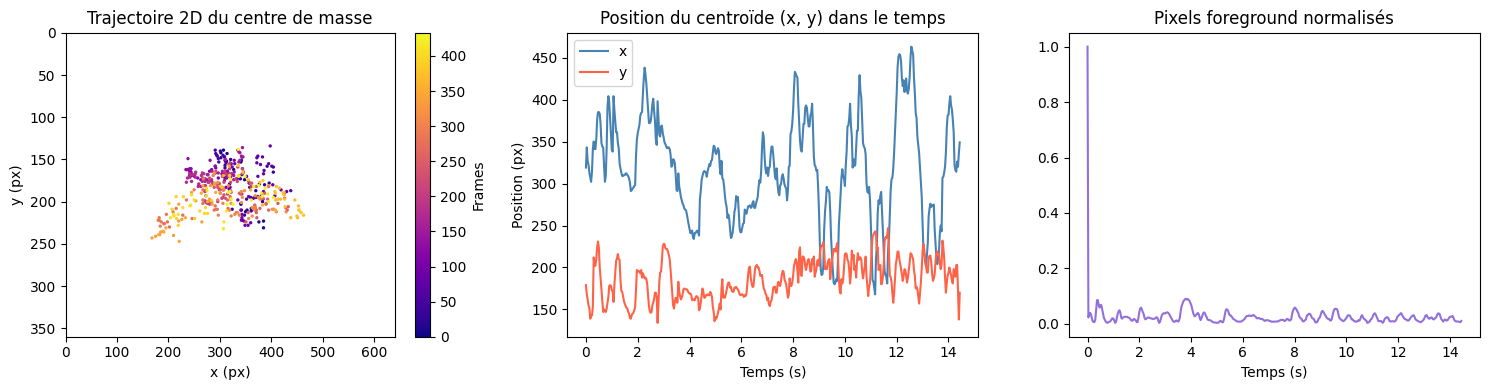


[OUTPUT_BGS] Sauvegardé


In [18]:
# CELLULE 5 : BACKGROUND SUBTRACTION & TRAJECTOIRE DU CENTRE DE MASSE

# --- Idée centrale ----------------------------------------------------
# MOG2 (Mixture of Gaussians v2) modélise le fond de la scène
# en apprenant la distribution statistique de chaque pixel sur
# les premières frames. Tout ce qui s'écarte de ce modèle = foreground.
# On calcule ensuite le centre de masse (centroïde) du masque binaire
# = une trajectoire 2D du mouvement sans tracker, sans ROI manuelle.

# history : nb de frames utilisées pour apprendre le fond
# varThreshold : sensibilité - plus élevé = moins de faux positifs
# detectShadows : détecte aussi les ombres (marquées en gris dans le masque)
bg_subtractor = cv2.createBackgroundSubtractorMOG2(
    history=100,
    varThreshold=50,
    detectShadows=False
)

cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame = cap.read()
frame = cv2.resize(frame, (FRAME_W, FRAME_H))

trajectory_x = []
trajectory_y = []
fg_signal = [] # nb de pixels foreground par frame = intensité du mouvement

OUTPUT_BGS = "resultat_bgs.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_BGS, fourcc, FPS, (FRAME_W * 2, FRAME_H))

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (FRAME_W, FRAME_H))

    # Application du modèle -> masque binaire (255:foreground, 0:fond)
    fg_mask = bg_subtractor.apply(frame)

    # Nettoyage morphologique : supprime les petits bruits isolés
    # MORPH_OPEN = érosion puis dilatation = élimine les points parasites
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel)

    fg_pixels = int(np.sum(fg_mask > 0))
    fg_signal.append(fg_pixels)

    # Centroïde du masque = centre de masse du mouvement détecté
    # cv2.moments calcule les moments géométriques du masque binaire
    # m00 = aire, m10/m00 = x moyen, m01/m00 = y moyen
    M = cv2.moments(fg_mask)
    if M["m00"] > 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        trajectory_x.append(cx)
        trajectory_y.append(cy)
    else:
        # Pas de foreground = on répète la dernière position connue
        if trajectory_x:
            trajectory_x.append(trajectory_x[-1])
            trajectory_y.append(trajectory_y[-1])

    # Dessin de la trajectoire sur la frame (toutes les positions précédentes)
    annotated = frame.copy()
    for k in range(1, len(trajectory_x)):
        alpha = k / len(trajectory_x) # plus récent = plus vif
        color = (0, int(255 * alpha), int(255 * (1 - alpha)))
        cv2.line(annotated,
                 (trajectory_x[k-1], trajectory_y[k-1]),
                 (trajectory_x[k], trajectory_y[k]),
                 color, 2)

    if trajectory_x:
        cv2.circle(annotated, (trajectory_x[-1], trajectory_y[-1]),
                   5, (0, 255, 255), -1) # point courant en jaune

    # Masque en BGR pour le side-by-side
    fg_bgr = cv2.cvtColor(fg_mask, cv2.COLOR_GRAY2BGR)
    cv2.putText(fg_bgr, "Foreground", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)
    cv2.putText(annotated, "Trajectoire", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

    combined = np.hstack([annotated, fg_bgr])
    out.write(combined)

    cv2.imshow("Trajectoire | Foreground - Q pour quitter", combined)
    if cv2.waitKey(1) & 0xFF in [27, ord('q')]:
        break

cap.release()
out.release()
cv2.destroyAllWindows()

# --- Visualisation finale ---------------------------------------------
trajectory_x = np.array(trajectory_x)
trajectory_y = np.array(trajectory_y)
time = np.arange(len(fg_signal)) / FPS
fg_signal = np.array(fg_signal, dtype=np.float32)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Trajectoire 2D du centre de masse
sc = axes[0].scatter(trajectory_x, trajectory_y,
                     c=np.arange(len(trajectory_x)), cmap='plasma', s=2)
axes[0].invert_yaxis() # y=0 en haut comme OpenCV
axes[0].set_xlim(0, FRAME_W)
axes[0].set_ylim(FRAME_H, 0)
axes[0].set_title("Trajectoire 2D du centre de masse")
axes[0].set_xlabel("x (px)"); axes[0].set_ylabel("y (px)")
plt.colorbar(sc, ax=axes[0], label="Frames")

# Coordonnées x et y en fonction du temps
axes[1].plot(time[:len(trajectory_x)], trajectory_x, color="steelblue", label="x")
axes[1].plot(time[:len(trajectory_y)], trajectory_y, color="tomato", label="y")
axes[1].set_title("Position du centroïde (x, y) dans le temps")
axes[1].set_xlabel("Temps (s)"); axes[1].set_ylabel("Position (px)")
axes[1].legend()

# Nombre de pixels foreground = proxy de l'intensité du mouvement global
axes[2].plot(time, fg_signal / fg_signal.max(), color="mediumpurple")
axes[2].set_title("Pixels foreground normalisés")
axes[2].set_xlabel("Temps (s)")

plt.tight_layout()
plt.show()
print(f"\n[OUTPUT_BGS] Sauvegardé")

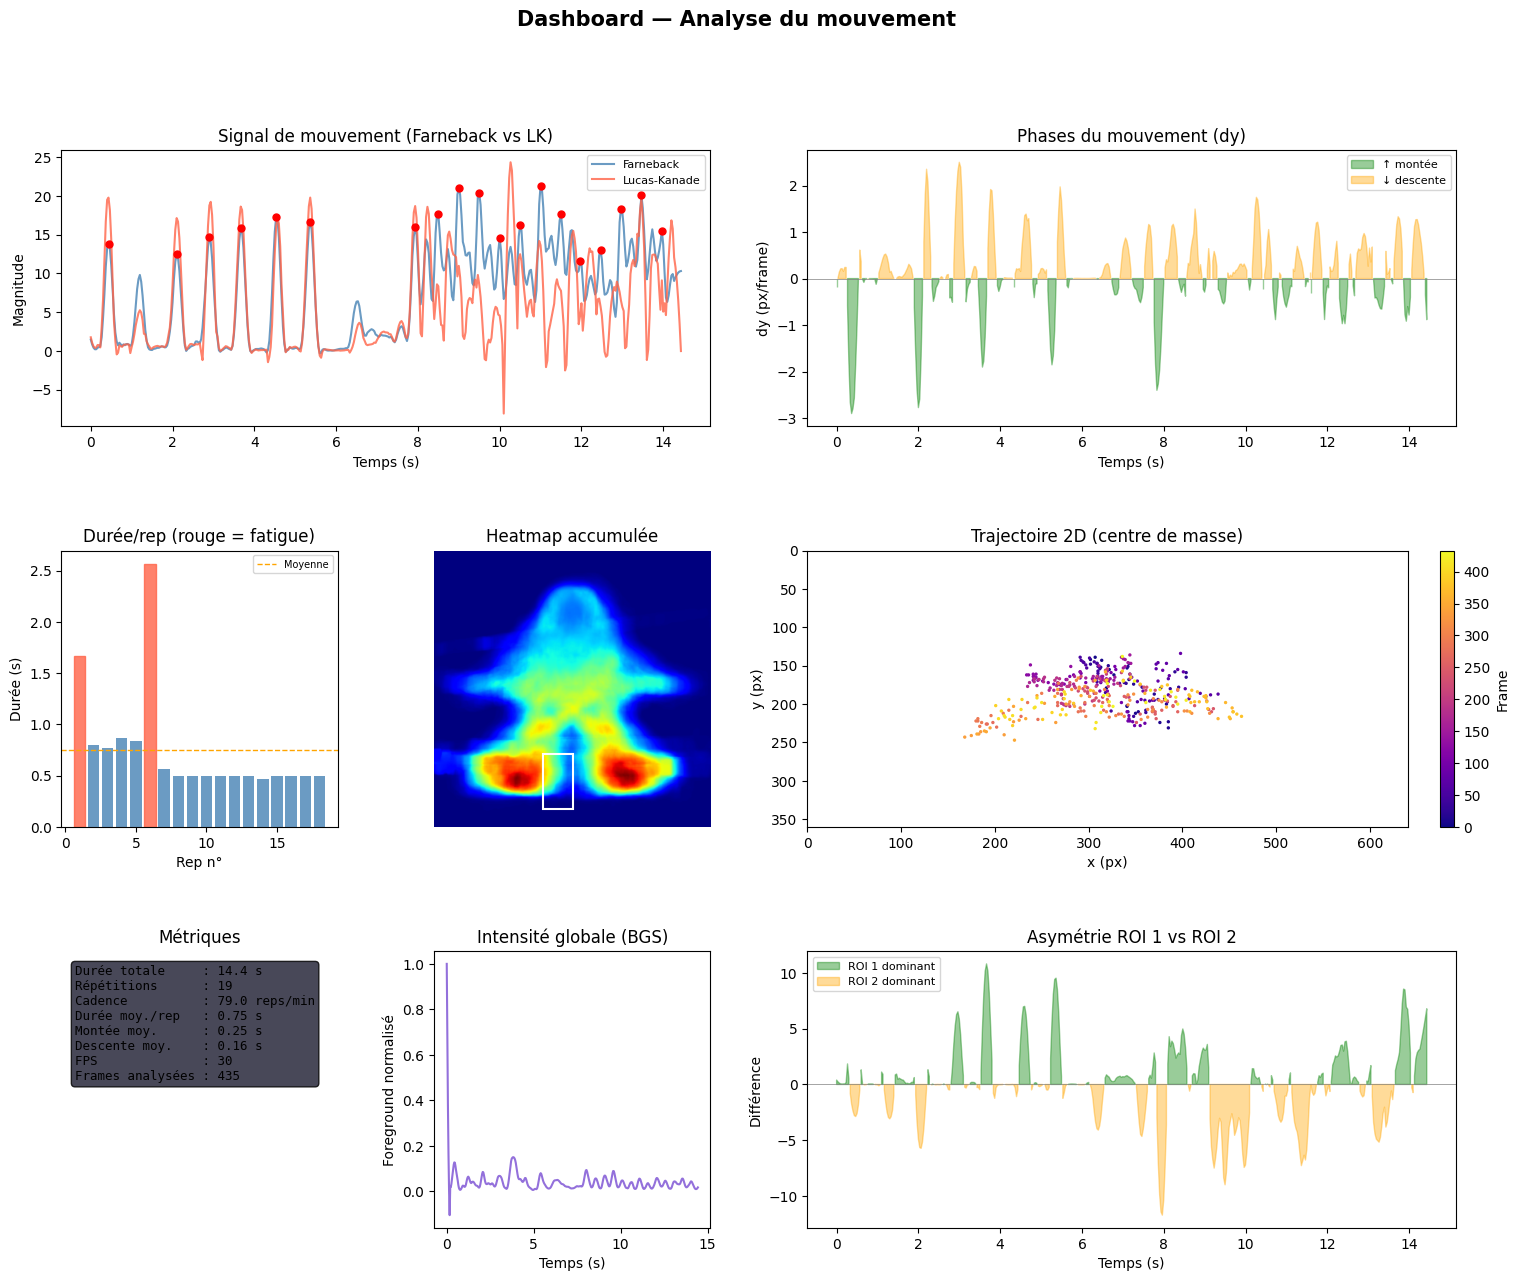

dashboard_final.png sauvegardé


In [14]:
# ── Récapitulatif de toutes les métriques extraites ─────────────────────
# On regroupe ici tout ce qu'on a calculé dans les cellules précédentes
# dans un seul dashboard matplotlib + un résumé texte exportable.

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Dashboard — Analyse du mouvement", fontsize=15, fontweight="bold")

gs = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

times_main = np.arange(len(signal_smooth)) / FPS

# ──  signaux ───────────────────────────────────────────────────

# [0,0:2] Signal Farneback + LK superposés
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(times_main, signal_smooth,  color="steelblue", label="Farneback", alpha=0.8)
ax1.plot(times_main[:len(signal_lk_smooth)], signal_lk_smooth,
         color="tomato", label="Lucas-Kanade", alpha=0.8)
ax1.scatter(times_main[peaks], signal_smooth[peaks],
            color="red", s=25, zorder=5)
ax1.set_title("Signal de mouvement (Farneback vs LK)")
ax1.set_xlabel("Temps (s)"); ax1.set_ylabel("Magnitude")
ax1.legend(fontsize=8)

# [0,2:4] Phases concentrique / excentrique
ax2 = fig.add_subplot(gs[0, 2:])
dy_s = savgol_filter(signal_dy, window_length=11, polyorder=2)
t_dy = np.arange(len(dy_s)) / FPS
ax2.fill_between(t_dy, dy_s, 0,
    where=(dy_s < 0), alpha=0.4, color="green",  label="↑ montée")
ax2.fill_between(t_dy, dy_s, 0,
    where=(dy_s > 0), alpha=0.4, color="orange", label="↓ descente")
ax2.axhline(0, color="gray", linewidth=0.5)
ax2.set_title("Phases du mouvement (dy)")
ax2.set_xlabel("Temps (s)"); ax2.set_ylabel("dy (px/frame)")
ax2.legend(fontsize=8)

# ── durée des reps + heatmap + trajectoire ────────────────────

# [1,0] Durée par répétition
ax3 = fig.add_subplot(gs[1, 0])
if nb_reps > 1:
    inter_peak = np.diff(peaks) / FPS
    bars = ax3.bar(range(1, nb_reps), inter_peak,
                   color="steelblue", alpha=0.8)
    ax3.axhline(inter_peak.mean(), color="orange",
                linestyle="--", linewidth=1, label="Moyenne")
    # Colorie en rouge les reps plus lentes que moyenne + 20% (fatigue)
    fatigue_threshold = inter_peak.mean() * 1.2
    for bar, val in zip(bars, inter_peak):
        if val > fatigue_threshold:
            bar.set_color("tomato")
    ax3.legend(fontsize=7)
ax3.set_title("Durée/rep (rouge = fatigue)")
ax3.set_xlabel("Rep n°"); ax3.set_ylabel("Durée (s)")
# [1,1] Heatmap
ax4 = fig.add_subplot(gs[1, 1])
ax4.imshow(heatmap, cmap="jet", aspect="auto")
rx, ry, rw, rh = ROI
rect = plt.Rectangle((rx, ry), rw, rh,
    edgecolor="white", facecolor="none", linewidth=1.5)
ax4.add_patch(rect)
ax4.set_title("Heatmap accumulée")
ax4.axis("off")

# [1,2:4] Trajectoire 2D centre de masse
ax5 = fig.add_subplot(gs[1, 2:])
sc = ax5.scatter(trajectory_x, trajectory_y,
    c=np.arange(len(trajectory_x)), cmap="plasma", s=2)
ax5.invert_yaxis()
ax5.set_xlim(0, FRAME_W); ax5.set_ylim(FRAME_H, 0)
ax5.set_title("Trajectoire 2D (centre de masse)")
ax5.set_xlabel("x (px)"); ax5.set_ylabel("y (px)")
plt.colorbar(sc, ax=ax5, label="Frame", fraction=0.025)
# ──  métriques texte + foreground + symétrie ───────────────────

# [2,0] Carte de métriques texte
ax6 = fig.add_subplot(gs[2, 0])
ax6.axis("off")
metrics_lines = [
    f"Durée totale     : {times_main[-1]:.1f} s",
    f"Répétitions      : {nb_reps}",
    f"Cadence          : {cadence:.1f} reps/min",
    f"Durée moy./rep   : {avg_rep_duration:.2f} s",
    f"Montée moy.      : {up_durations.mean():.2f} s" if len(up_durations) > 0 else "Montée moy.      : —",
    f"Descente moy.    : {down_durations.mean():.2f} s" if len(down_durations) > 0 else "Descente moy.    : —",
    f"FPS              : {FPS:.0f}",
    f"Frames analysées : {TOTAL_FRAMES}",
]
ax6.text(0.05, 0.95, "\n".join(metrics_lines),
    transform=ax6.transAxes, fontsize=9, verticalalignment="top",
    fontfamily="monospace",
    bbox=dict(boxstyle="round", facecolor="#1a1a2e", alpha=0.8))
ax6.set_title("Métriques")
# [2,1] Pixels foreground (intensité globale du mouvement)
ax7 = fig.add_subplot(gs[2, 1])
fg_s = savgol_filter(fg_signal.astype(np.float32), window_length=11, polyorder=2)
ax7.plot(times, fg_s / fg_s.max(), color="mediumpurple")
ax7.set_title("Intensité globale (BGS)")
ax7.set_xlabel("Temps (s)"); ax7.set_ylabel("Foreground normalisé")

# [2,2:4] Asymétrie multi-ROI si disponible
ax8 = fig.add_subplot(gs[2, 2:])
if len(signals_smooth) >= 2:
    t_roi = np.arange(len(signals_smooth[0])) / FPS
    diff  = signals_smooth[0] - signals_smooth[1]
    ax8.fill_between(t_roi, diff, 0,
        where=(diff > 0), alpha=0.4, color="green",  label="ROI 1 dominant")
    ax8.fill_between(t_roi, diff, 0,
        where=(diff < 0), alpha=0.4, color="orange", label="ROI 2 dominant")
    ax8.axhline(0, color="gray", linewidth=0.5)
    ax8.legend(fontsize=8)
    ax8.set_title("Asymétrie ROI 1 vs ROI 2")
    ax8.set_xlabel("Temps (s)"); ax8.set_ylabel("Différence")
else:
    ax8.text(0.5, 0.5, "Multi-ROI non exécuté\n(cellule 12)",
             ha="center", va="center", transform=ax8.transAxes,
             color="gray", fontsize=10)
    ax8.axis("off")

plt.savefig("dashboard_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("dashboard_final.png sauvegardé")